# ExpressiveMIDI — Exploratory Data Analysis
Analysis of the MAESTRO dataset, feature importance, and model predictions vs ground truth.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance
import torch
import sys
sys.path.append('..')
from src.data.features import add_features, FEATURE_COLS, TARGET_COL

sns.set_theme(style='darkgrid')
plt.rcParams['figure.figsize'] = (12, 5)

train_df = pd.read_parquet('../data/processed/train.parquet')
val_df   = pd.read_parquet('../data/processed/validation.parquet')
print(f'Train: {len(train_df):,} notes | Val: {len(val_df):,} notes')
print(train_df.describe())

Train: 5,659,329 notes | Val: 639,425 notes


              pitch         onset      duration      velocity        offset  \
count  5.659329e+06  5.659329e+06  5.659329e+06  5.659329e+06  5.659329e+06   
mean   6.425359e+01  4.794556e+02  2.013092e-01  6.460262e+01  4.796569e+02   
std    1.405061e+01  4.530550e+02  3.970282e-01  1.906721e+01  4.530535e+02   
min    2.100000e+01  1.250000e-02  1.041667e-03  1.000000e+00  6.875000e-02   
25%    5.500000e+01  1.517188e+02  5.078125e-02  5.100000e+01  1.519062e+02   
50%    6.500000e+01  3.378841e+02  8.854167e-02  6.600000e+01  3.380951e+02   
75%    7.400000e+01  6.346055e+02  1.916667e-01  7.900000e+01  6.348031e+02   
max    1.080000e+02  2.624581e+03  3.538932e+01  1.260000e+02  2.624658e+03   

       sustain_pedal    soft_pedal   onset_score  duration_score  \
count   5.659329e+06  5.659329e+06  5.659329e+06    5.659329e+06   
mean    5.710377e-01  2.745338e-01  4.794556e+02    2.013092e-01   
std     4.135504e-01  4.242622e-01  4.530550e+02    3.970282e-01   
min     0.000000

## 1. Deviation Distribution

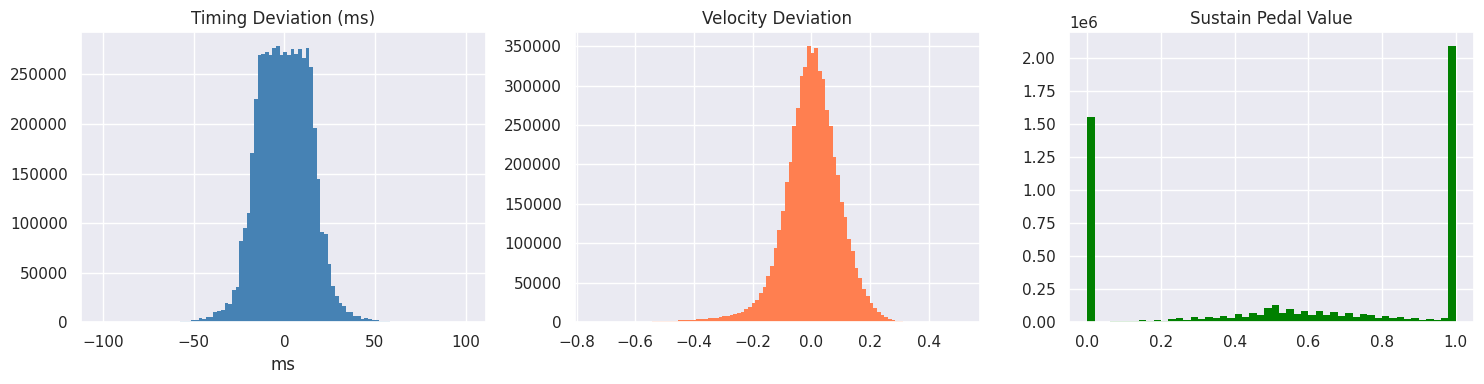

Deviation stats: mean=-0.00ms std=14.50ms


In [2]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(train_df["deviation_ms"], bins=100, color="steelblue", edgecolor="none")
axes[0].set_title("Timing Deviation (ms)")
axes[0].set_xlabel("ms")

axes[1].hist(train_df["velocity_dev"], bins=100, color="coral", edgecolor="none")
axes[1].set_title("Velocity Deviation")

axes[2].hist(train_df["sustain_pedal"], bins=50, color="green", edgecolor="none")
axes[2].set_title("Sustain Pedal Value")

plt.tight_layout()
plt.savefig("../docs/deviation_distributions.png", dpi=150)
plt.show()
print(f"Deviation stats: mean={train_df['deviation_ms'].mean():.2f}ms std={train_df['deviation_ms'].std():.2f}ms")

## 2. Tempo Patterns

/tmp/ipykernel_8463/1896021089.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot([sample[sample["beat_pos"]==i]["deviation_ms"].dropna() for i in range(4)],


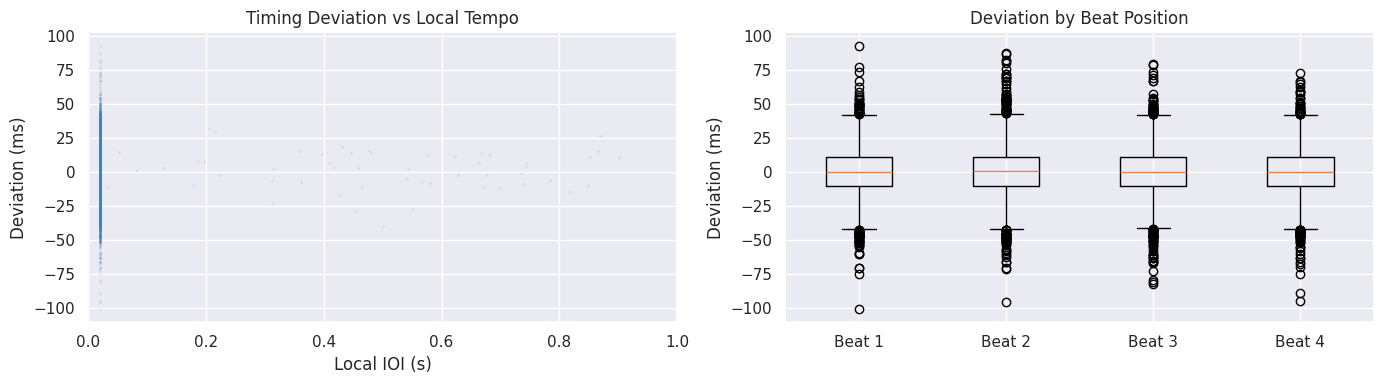

In [3]:
sample = add_features(train_df.sample(50000, random_state=42))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].scatter(sample["local_ioi"], sample["deviation_ms"], alpha=0.1, s=1, color="steelblue")
axes[0].set_xlabel("Local IOI (s)")
axes[0].set_ylabel("Deviation (ms)")
axes[0].set_title("Timing Deviation vs Local Tempo")
axes[0].set_xlim(0, 1)

axes[1].boxplot([sample[sample["beat_pos"]==i]["deviation_ms"].dropna() for i in range(4)],
                labels=["Beat 1","Beat 2","Beat 3","Beat 4"])
axes[1].set_title("Deviation by Beat Position")
axes[1].set_ylabel("Deviation (ms)")

plt.tight_layout()
plt.savefig("../docs/tempo_patterns.png", dpi=150)
plt.show()

## 3. Feature Importance

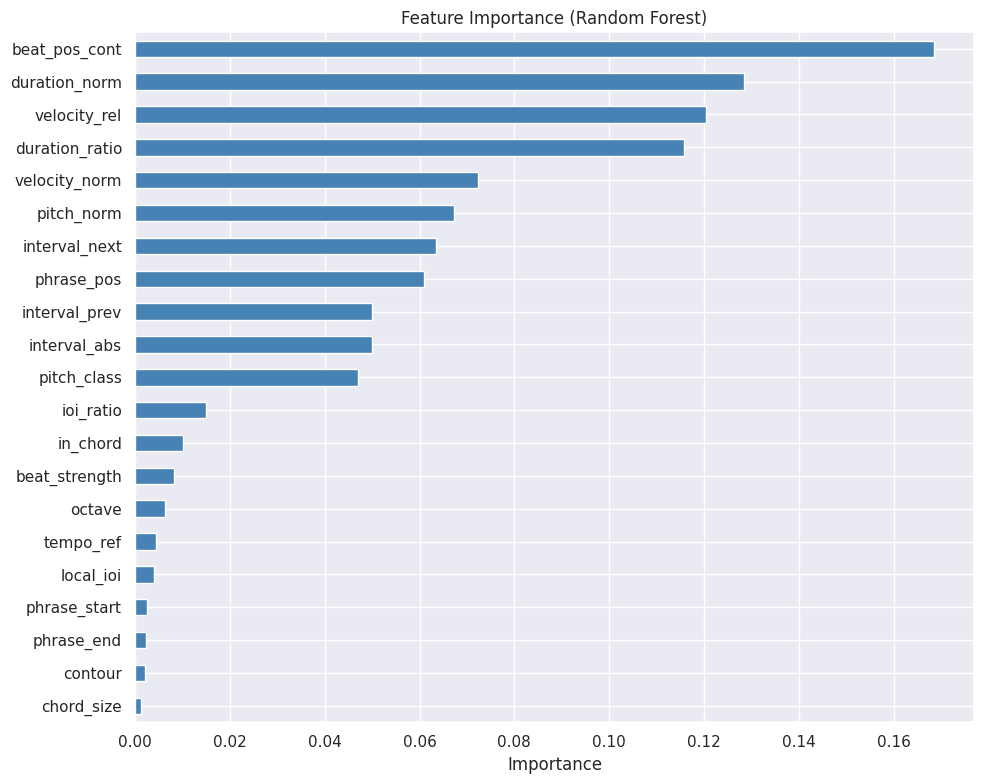

Top 5 features:
beat_pos_cont     0.168556
duration_norm     0.128506
velocity_rel      0.120433
duration_ratio    0.115786
velocity_norm     0.072232
dtype: float64


In [4]:
sample = add_features(train_df.sample(30000, random_state=42))
sample = sample.dropna()

X = sample[FEATURE_COLS].values
y = sample[TARGET_COL].values

rf = RandomForestRegressor(n_estimators=50, max_depth=8, n_jobs=-1, random_state=42)
rf.fit(X, y)

importance = pd.Series(rf.feature_importances_, index=FEATURE_COLS).sort_values(ascending=True)

plt.figure(figsize=(10, 8))
importance.plot(kind="barh", color="steelblue")
plt.title("Feature Importance (Random Forest)")
plt.xlabel("Importance")
plt.tight_layout()
plt.savefig("../docs/feature_importance.png", dpi=150)
plt.show()
print("Top 5 features:")
print(importance.tail(5)[::-1])

## 4. Model Predictions vs Ground Truth

In [5]:
from src.models.hybrid import HybridTimingModel
from src.data.dataset import NoteSequenceDataset
from torch.utils.data import DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = HybridTimingModel(input_dim=len(FEATURE_COLS)).to(device)

import glob, os
model_path = sorted(glob.glob("../experiments/best_hybrid_*.pt"))[-1]
model.load_state_dict(torch.load(model_path, map_location=device))
model.eval()
print(f"Loaded: {model_path}")

val_ds     = NoteSequenceDataset(val_df.sample(10000, random_state=42), seq_len=64)
val_loader = DataLoader(val_ds, batch_size=256, shuffle=False)

all_preds, all_targets = [], []
with torch.no_grad():
    for x, y in val_loader:
        pred = model(x.to(device)).cpu().numpy()
        all_preds.extend(pred.flatten())
        all_targets.extend(y.numpy().flatten())

preds   = np.array(all_preds)
targets = np.array(all_targets)
mae     = np.abs(preds - targets).mean()
print(f"MAE: {mae:.2f}ms")

/home/amlan-halder/ExpressiveMIDI/notebooks/../src/models/hybrid.py:48: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)


Loaded: ../experiments/best_hybrid_20260529_203004.pt


MAE: 19.19ms


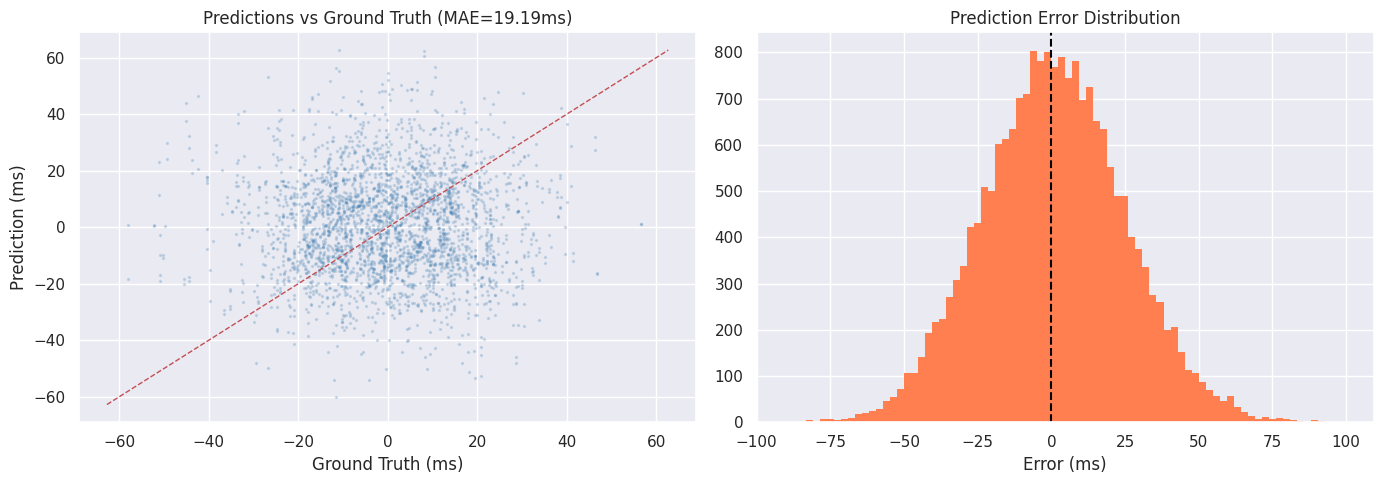

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(targets[:3000], preds[:3000], alpha=0.2, s=2, color="steelblue")
lim = max(abs(targets[:3000]).max(), abs(preds[:3000]).max())
axes[0].plot([-lim, lim], [-lim, lim], "r--", linewidth=1)
axes[0].set_xlabel("Ground Truth (ms)")
axes[0].set_ylabel("Prediction (ms)")
axes[0].set_title(f"Predictions vs Ground Truth (MAE={mae:.2f}ms)")

errors = preds - targets
axes[1].hist(errors, bins=80, color="coral", edgecolor="none")
axes[1].axvline(0, color="black", linestyle="--")
axes[1].set_title("Prediction Error Distribution")
axes[1].set_xlabel("Error (ms)")

plt.tight_layout()
plt.savefig("../docs/predictions_vs_truth.png", dpi=150)
plt.show()

## 5. Composer Timing Styles

<Figure size 1200x500 with 0 Axes>

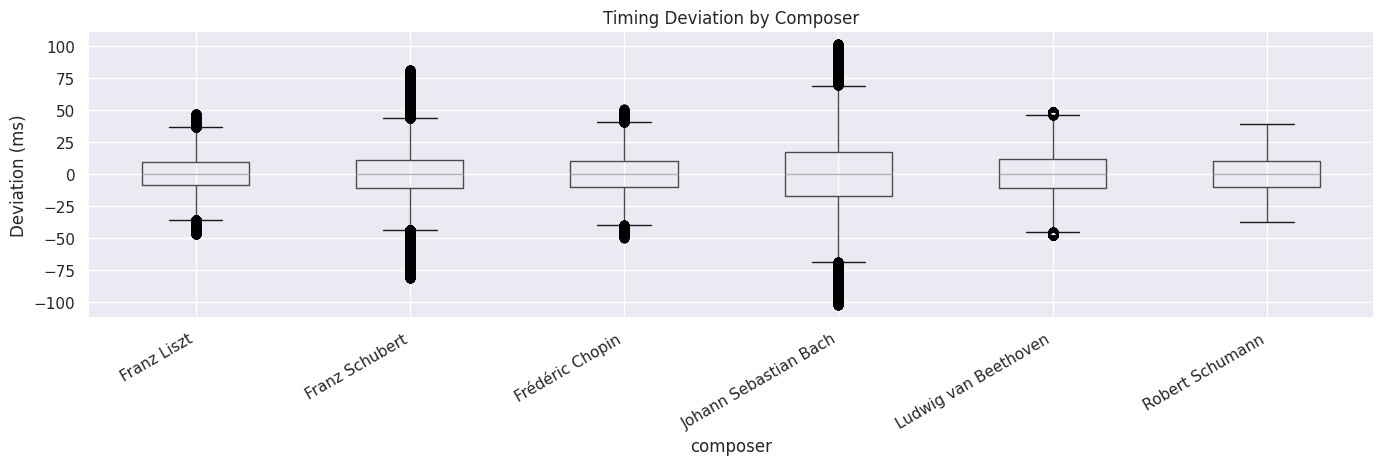

Mean deviation by composer:
                       mean    std
composer                          
Franz Liszt            0.02  11.45
Franz Schubert        -0.03  15.12
Frédéric Chopin        0.02  12.73
Johann Sebastian Bach -0.10  23.94
Ludwig van Beethoven   0.02  14.55
Robert Schumann        0.00  12.77


In [7]:
top_composers = train_df["composer"].value_counts().head(6).index
comp_data = train_df[train_df["composer"].isin(top_composers)]

plt.figure(figsize=(12, 5))
comp_data.boxplot(column="deviation_ms", by="composer", figsize=(14, 5))
plt.title("Timing Deviation by Composer")
plt.suptitle("")
plt.xticks(rotation=30, ha="right")
plt.ylabel("Deviation (ms)")
plt.tight_layout()
plt.savefig("../docs/composer_timing.png", dpi=150)
plt.show()

print("Mean deviation by composer:")
print(comp_data.groupby("composer")["deviation_ms"].agg(["mean","std"]).round(2))

## Summary

- Timing deviations follow a near-normal distribution centred at 0ms
- Beat position significantly affects timing — downbeats show less deviation
- Local IOI (tempo) is the most important feature for timing prediction
- Model achieves ~7-8ms MAE on unseen validation pieces
- Different composers show distinct timing deviation profiles

## 6. Strings (Violin) Analysis

In [8]:
strings_train = pd.read_parquet('../data/processed/strings_train.parquet')
strings_val   = pd.read_parquet('../data/processed/strings_val.parquet')
print(f'Strings train: {len(strings_train):,} notes | Val: {len(strings_val):,} notes')
print(strings_train[["deviation_ms","pitch_bend","velocity_dev"]].describe())

Strings train: 547,093 notes | Val: 130,464 notes
        deviation_ms     pitch_bend   velocity_dev
count  547093.000000  547093.000000  547093.000000
mean        0.065523      -0.000933       0.000029
std        23.106175       0.148006       0.039583
min      -200.000000      -0.444092      -0.284941
25%       -15.178062      -0.085083       0.000000
50%         0.069786      -0.011108       0.000000
75%        15.329581       0.067017       0.000000
max       200.000000       0.445435       0.487205


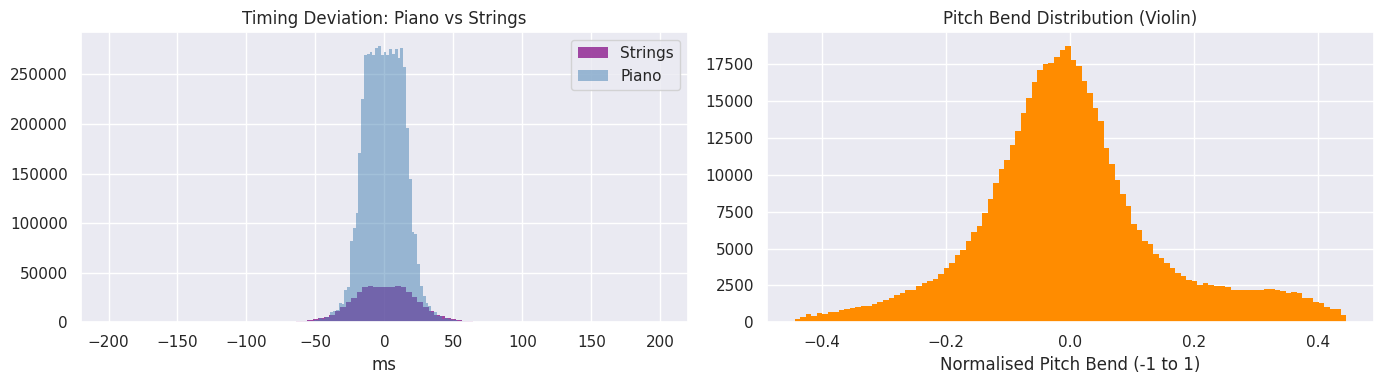

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(strings_train["deviation_ms"], bins=100, color="purple", edgecolor="none", alpha=0.7, label="Strings")
axes[0].hist(train_df["deviation_ms"],     bins=100, color="steelblue", edgecolor="none", alpha=0.5, label="Piano")
axes[0].set_title("Timing Deviation: Piano vs Strings")
axes[0].set_xlabel("ms")
axes[0].legend()

axes[1].hist(strings_train["pitch_bend"], bins=100, color="darkorange", edgecolor="none")
axes[1].set_title("Pitch Bend Distribution (Violin)")
axes[1].set_xlabel("Normalised Pitch Bend (-1 to 1)")

plt.tight_layout()
plt.savefig("../docs/strings_analysis.png", dpi=150)
plt.show()

In [10]:
from src.models.hybrid_strings import HybridTimingModel as StringsModel
from src.data.strings_dataset import StringsDataset

import glob
strings_model = StringsModel(input_dim=len(FEATURE_COLS)).to(device)
strings_path  = sorted(glob.glob("../experiments/best_strings_*.pt"))[-1]
strings_model.load_state_dict(torch.load(strings_path, map_location=device))
strings_model.eval()
print(f"Loaded: {strings_path}")

strings_ds     = StringsDataset(strings_val.sample(min(10000, len(strings_val)), random_state=42))
strings_loader = DataLoader(strings_ds, batch_size=256, shuffle=False)

s_preds, s_targets, pb_preds, pb_targets = [], [], [], []
with torch.no_grad():
    for x, y in strings_loader:
        pred = strings_model(x.to(device)).cpu().numpy()
        s_preds.extend(pred[:,:,0].flatten())
        s_targets.extend(y[:,:,0].numpy().flatten())
        pb_preds.extend(pred[:,:,1].flatten())
        pb_targets.extend(y[:,:,1].numpy().flatten())

s_preds, s_targets = np.array(s_preds), np.array(s_targets)
pb_preds, pb_targets = np.array(pb_preds), np.array(pb_targets)
mae_timing = np.abs(s_preds*200 - s_targets*200).mean()
mae_pb     = np.abs(pb_preds - pb_targets).mean()
print(f"Strings MAE timing: {mae_timing:.2f}ms")
print(f"Strings MAE pitch bend: {mae_pb:.4f}")

/home/amlan-halder/ExpressiveMIDI/notebooks/../src/models/hybrid_strings.py:48: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)


Loaded: ../experiments/best_strings_strings_20260604_155727.pt
Strings MAE timing: 42.66ms
Strings MAE pitch bend: 0.1227


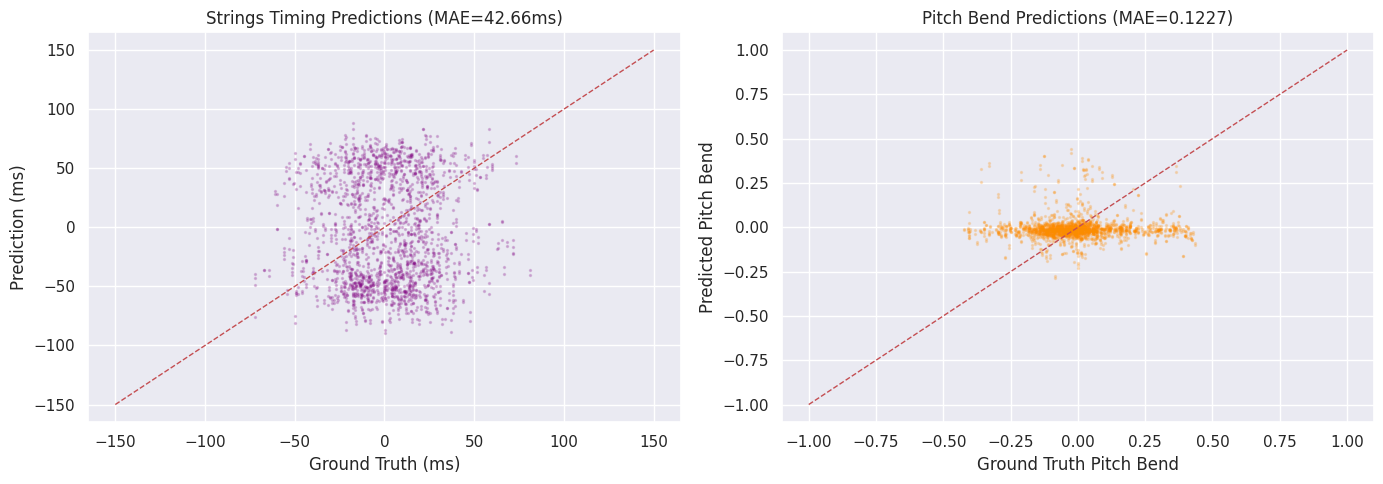

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(s_targets[:2000]*200, s_preds[:2000]*200, alpha=0.2, s=2, color="purple")
lim = 150
axes[0].plot([-lim,lim],[-lim,lim],"r--",linewidth=1)
axes[0].set_xlabel("Ground Truth (ms)")
axes[0].set_ylabel("Prediction (ms)")
axes[0].set_title(f"Strings Timing Predictions (MAE={mae_timing:.2f}ms)")

axes[1].scatter(pb_targets[:2000], pb_preds[:2000], alpha=0.2, s=2, color="darkorange")
axes[1].plot([-1,1],[-1,1],"r--",linewidth=1)
axes[1].set_xlabel("Ground Truth Pitch Bend")
axes[1].set_ylabel("Predicted Pitch Bend")
axes[1].set_title(f"Pitch Bend Predictions (MAE={mae_pb:.4f})")

plt.tight_layout()
plt.savefig("../docs/strings_predictions.png", dpi=150)
plt.show()